# ARX Baseline V3

V3 giữ nguyên V2 và chỉ thêm intercept để kiểm tra tác động của offset sau normalization:

- `ARX(2,2,1)`
- 6 input gốc
- OLS
- không feature engineering
- không Ridge/Lasso
- không clip free-run
- z-score normalization bằng thống kê train
- `include_intercept=True`


## 1. Import và cấu hình

Notebook có thể chạy từ project root hoặc từ thư mục `ARX_Model_Version`.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = Path.cwd()
PROJECT_ROOT = WORK_DIR.parent if WORK_DIR.name == "ARX_Model_Version" else WORK_DIR
VERSION_DIR = PROJECT_ROOT / "ARX_Model_Version"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from arx_pipeline import (
    DataConfig,
    SplitConfig,
    ModelConfig,
    load_or_generate_data,
    split_time_series,
    summarize_dataset_behavior,
    build_regression_matrix,
    estimate_ols,
    build_true_theta,
    evaluate_slice,
    summarize_parameters,
    compute_ar_roots,
    compute_metrics,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## 2. Cấu hình V3


In [2]:
DATA_CONFIG = DataConfig(
    csv_path=PROJECT_ROOT / "greenhouse_data.csv",
    generator_script_path=PROJECT_ROOT / "data_generator.py",
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
)

SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)

BASELINE_INPUT_COLS = (
    "Temperature",
    "Humidity",
    "Light",
    "Drip",
    "Mist",
    "Fan",
)

V3_CONFIG = ModelConfig(
    na=2,
    nb=2,
    nk=1,
    include_intercept=True,
    input_cols=BASELINE_INPUT_COLS,
    output_col="Soil_Moisture",
    simulation_clip=None,
)

SCALE_COLS = ("Soil_Moisture", *BASELINE_INPUT_COLS)
V3_CONFIG


ModelConfig(na=2, nb=2, nk=1, include_intercept=True, input_cols=('Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan'), output_col='Soil_Moisture', simulation_clip=None)

## 3. Load data và chia train/validation/test


In [3]:
df_full, true_params, data_source = load_or_generate_data(DATA_CONFIG)
df_train, df_val, df_test = split_time_series(df_full, SPLIT_CONFIG)

overview = pd.DataFrame([
    summarize_dataset_behavior(df_full, "Full"),
    summarize_dataset_behavior(df_train, "Train"),
    summarize_dataset_behavior(df_val, "Validation"),
    summarize_dataset_behavior(df_test, "Test"),
])

print("Nguồn dữ liệu:", data_source)
print("Số dòng:", len(df_full), "| Train:", len(df_train), "| Validation:", len(df_val), "| Test:", len(df_test))
overview


Nguồn dữ liệu: CSV:greenhouse_data.csv
Số dòng: 105120 | Train: 63072 | Validation: 21024 | Test: 21024


,label,rows,timestamp_start,timestamp_end,months_present,seasons_present,drip_on_pct,drip_switches,mist_on_pct,mist_switches,fan_on_pct,fan_switches,below_sp_pct,inside_sp_pct,above_sp_pct
0,Full,105120,2025-01-01 00:00:00,2025-12-31 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[autumn, spring, summer, winter]",22.80,12533,7.89,8022,16.89,12768,23.09,76.35,0.56
1,Train,63072,2025-01-01 00:00:00,2025-08-07 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8]","[spring, summer, winter]",22.95,7546,7.81,4760,17.46,7865,23.30,76.13,0.57
2,Validation,21024,2025-08-08 00:00:00,2025-10-19 23:55:00,"[8, 9, 10]","[autumn, summer]",23.47,2558,9.77,1970,19.34,2817,23.84,75.75,0.41
3,Test,21024,2025-10-20 00:00:00,2025-12-31 23:55:00,"[10, 11, 12]","[autumn, winter]",21.68,2429,6.25,1292,12.75,2085,21.70,77.61,0.69


## 4. Tính z-score từ train

Mean/std chỉ lấy từ train để tránh leakage sang validation/test.


In [4]:
scale_stats = {}
for col in SCALE_COLS:
    mean = float(df_train[col].astype(float).mean())
    std = float(df_train[col].astype(float).std(ddof=0))
    if not np.isfinite(std) or std < 1e-12:
        std = 1.0
    scale_stats[col] = {"mean": mean, "std": std}

pd.DataFrame(scale_stats).T


,mean,std
Soil_Moisture,57.468777,3.353448
Temperature,25.659789,3.578281
Humidity,73.492878,8.072112
Light,288.882555,344.246625
Drip,0.229484,0.420501
Mist,0.078133,0.268381
Fan,0.174610,0.379633


In [5]:
def apply_zscore(df_in: pd.DataFrame, stats: dict[str, dict[str, float]]) -> pd.DataFrame:
    df_out = df_in.copy()
    for col, st in stats.items():
        df_out[col] = (df_out[col].astype(float) - st["mean"]) / st["std"]
    return df_out


def inverse_y(values: np.ndarray) -> np.ndarray:
    st = scale_stats["Soil_Moisture"]
    return np.asarray(values, dtype=float) * st["std"] + st["mean"]


df_train_z = apply_zscore(df_train, scale_stats)
df_val_z = apply_zscore(df_val, scale_stats)
df_test_z = apply_zscore(df_test, scale_stats)

display(df_train_z[["Soil_Moisture", *BASELINE_INPUT_COLS]].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture,63072.0,-0.0,1.0,-2.6108,-0.7291,-0.0101,0.7299,3.7232
Temperature,63072.0,0.0,1.0,-3.2585,-0.5500,0.3686,0.7350,1.8414
Humidity,63072.0,-0.0,1.0,-5.3880,-0.6322,0.1200,0.8178,2.3772
Light,63072.0,0.0,1.0,-0.8392,-0.8114,-0.7577,0.9206,2.5971
Drip,63072.0,-0.0,1.0,-0.5457,-0.5457,-0.5457,-0.5457,1.8324
Mist,63072.0,0.0,1.0,-0.2911,-0.2911,-0.2911,-0.2911,3.4349
Fan,63072.0,-0.0,1.0,-0.4599,-0.4599,-0.4599,-0.4599,2.1742


## 5. Fit OLS trên dữ liệu đã normalize


In [6]:
X_train_z, y_train_z = build_regression_matrix(df_train_z, V3_CONFIG)
theta_hat_z, cov_hat_z, sigma2_hat_z = estimate_ols(X_train_z, y_train_z)
true_theta = build_true_theta(true_params, V3_CONFIG)

matrix_info = pd.Series({
    "x_train_shape": X_train_z.shape,
    "y_train_shape": y_train_z.shape,
    "rank_x_train": int(np.linalg.matrix_rank(X_train_z)),
    "condition_number_xtx": float(np.linalg.cond(X_train_z.T @ X_train_z)),
    "sigma2_hat_scaled": float(sigma2_hat_z),
})

matrix_info


x_train_shape           (63070, 15)
y_train_shape              (63070,)
rank_x_train                     15
condition_number_xtx    5311.574975
sigma2_hat_scaled          0.005556
dtype: object

## 6. Bảng tham số scaled


In [7]:
param_df = pd.DataFrame(summarize_parameters(theta_hat_z, cov_hat_z, V3_CONFIG, true_params))
param_df


,name,estimate,std,ci95_low,ci95_high,true_value,delta_vs_true,sign_ok
0,a1,9.629338e-01,0.001681,0.959638,0.966229,0.96500,-0.002066,True
1,a2,2.708141e-02,0.001771,0.023610,0.030552,0.02500,0.002081,True
2,b_Temperature_1,-7.632915e-03,0.002737,-0.012998,-0.002268,-0.00800,0.000367,True
3,b_Temperature_2,-4.231292e-03,0.002661,-0.009446,0.000983,-0.00400,-0.000231,True
4,b_Humidity_1,6.808135e-03,0.002143,0.002608,0.011009,0.00250,0.004308,True
5,b_Humidity_2,2.148728e-03,0.002023,-0.001816,0.006113,0.00120,0.000949,True
6,b_Light_1,-1.412166e-02,0.007238,-0.028309,0.000065,-0.00022,-0.013902,True
7,b_Light_2,-1.938295e-02,0.007320,-0.033731,-0.005035,-0.00010,-0.019283,True
8,b_Drip_1,1.569760e-01,0.000437,0.156119,0.157833,1.25000,-1.093024,True
9,b_Drip_2,2.322288e-01,0.000686,0.230884,0.233574,1.85000,-1.617771,True


## 7. Đánh giá Train / Validation / Test

FIT không đổi theo phép đổi đơn vị tuyến tính, nhưng RMSE được báo lại theo đơn vị `Soil_Moisture` thật.


In [8]:
train_eval_z = evaluate_slice("Train", df_train_z, theta_hat_z, V3_CONFIG, true_theta=true_theta, n_step=12)
val_eval_z = evaluate_slice("Validation", df_val_z, theta_hat_z, V3_CONFIG, true_theta=true_theta, n_step=12)
test_eval_z = evaluate_slice("Test", df_test_z, theta_hat_z, V3_CONFIG, true_theta=true_theta, n_step=12)


def real_unit_metrics(ev: dict, mode: str) -> dict[str, float]:
    arrays = ev["arrays"]
    if mode == "1step":
        y_true = inverse_y(arrays["y_true_1step"])
        y_pred = inverse_y(arrays["y_pred_1step"])
    elif mode == "12step":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_n_step"])
    elif mode == "sim":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_sim"])
    else:
        raise ValueError(mode)
    return compute_metrics(y_true, y_pred, len(theta_hat_z))


def metric_row(split_name: str, ev: dict) -> dict[str, float | str]:
    m1 = real_unit_metrics(ev, "1step")
    m12 = real_unit_metrics(ev, "12step")
    msim = real_unit_metrics(ev, "sim")
    return {
        "split": split_name,
        "FIT_1step": m1["FIT"],
        "RMSE_1step": m1["RMSE"],
        "FIT_12step": m12["FIT"],
        "RMSE_12step": m12["RMSE"],
        "FIT_sim": msim["FIT"],
        "RMSE_sim": msim["RMSE"],
        "Bias_sim": msim["Bias"],
    }


metrics_df = pd.DataFrame([
    metric_row("Train", train_eval_z),
    metric_row("Validation", val_eval_z),
    metric_row("Test", test_eval_z),
]).round(4)

metrics_df


,split,FIT_1step,RMSE_1step,FIT_12step,RMSE_12step,FIT_sim,RMSE_sim,Bias_sim
0,Train,92.5471,0.2499,76.4349,0.7903,49.1111,1.7066,0.0052
1,Validation,91.6405,0.2510,73.0916,0.8078,42.4860,1.7266,0.1437
2,Test,91.3490,0.2520,72.6588,0.7964,43.3988,1.6486,0.1054


## 8. So sánh với V1/V2 artifact


In [9]:
v1_path_candidates = [
    VERSION_DIR / "arx_baseline_v1.json",
    PROJECT_ROOT / "arx_baseline_v1.json",
]
v2_path_candidates = [
    VERSION_DIR / "arx_baseline_v2.json",
    PROJECT_ROOT / "arx_baseline_v2.json",
]
v1_artifact = None
for path in v1_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v1_artifact = json.load(f)
        break
v2_artifact = None
for path in v2_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v2_artifact = json.load(f)
        break

if v1_artifact is None:
    comparison_df = pd.DataFrame()
else:
    rows = [
        {
            "version": "V1 raw OLS",
            "val_FIT_sim": v1_artifact["metrics"]["validation"]["fit_sim"],
            "test_FIT_sim": v1_artifact["metrics"]["test"]["fit_sim"],
        }
    ]
    if v2_artifact is not None:
        rows.append(
            {
                "version": "V2 z-score OLS",
                "val_FIT_sim": v2_artifact["metrics"]["validation"]["fit_sim"],
                "test_FIT_sim": v2_artifact["metrics"]["test"]["fit_sim"],
            }
        )
    rows.append(
        {
            "version": "V3 z-score + intercept OLS",
            "val_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Validation", "FIT_sim"].iloc[0]),
            "test_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Test", "FIT_sim"].iloc[0]),
        }
    )
    comparison_df = pd.DataFrame(rows)
    comparison_df["test_gain_vs_v1"] = comparison_df["test_FIT_sim"] - comparison_df.loc[0, "test_FIT_sim"]
    comparison_df["test_gain_vs_previous"] = comparison_df["test_FIT_sim"].diff()

comparison_df.round(4)


,version,val_FIT_sim,test_FIT_sim,test_gain_vs_v1,test_gain_vs_previous
0,V1 raw OLS,42.9588,43.8749,0.0000,NaN
1,V2 z-score OLS,42.4854,43.3983,-0.4767,-0.4767
2,V3 z-score + intercept OLS,42.4860,43.3988,-0.4761,0.0005


## 9. Vẽ free-run simulation


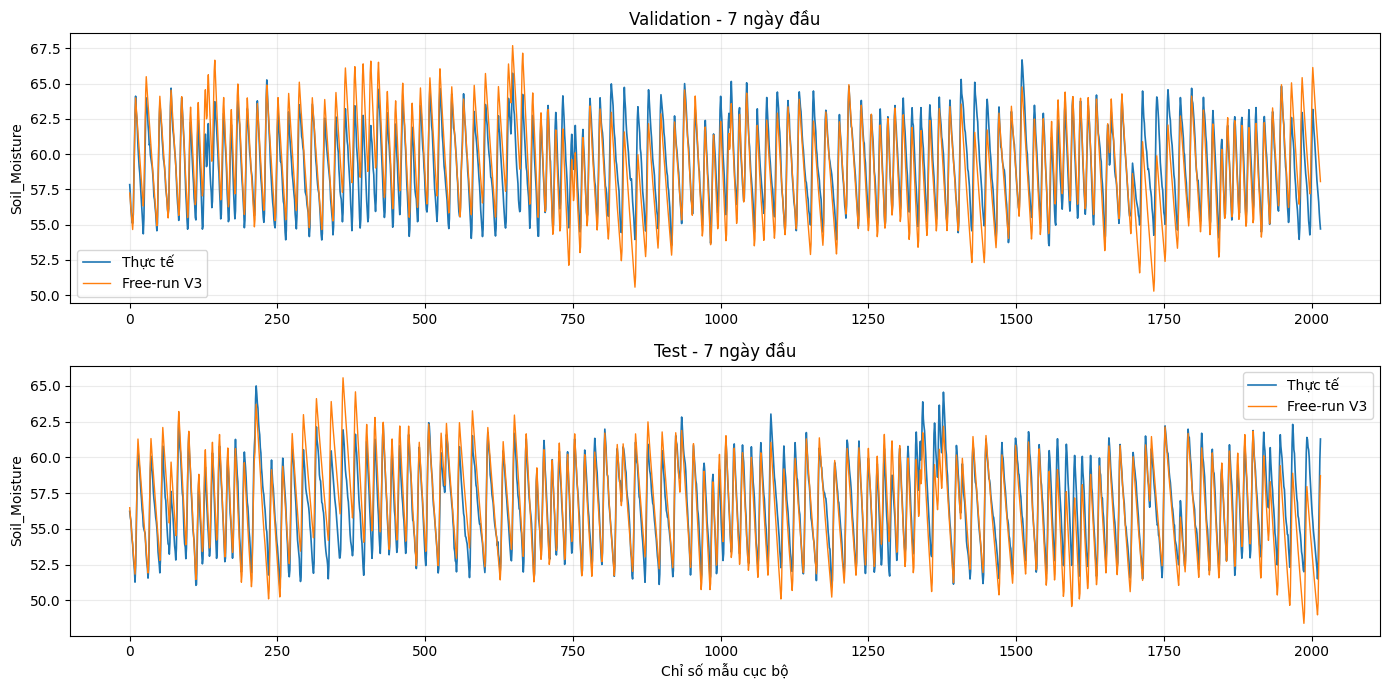

In [10]:
def prediction_frame_real(ev: dict, split_name: str) -> pd.DataFrame:
    arrays = ev["arrays"]
    n = len(arrays["y_true_sim"])
    return pd.DataFrame({
        "split": split_name,
        "idx": np.arange(n),
        "y_true": inverse_y(arrays["y_true_sim"]),
        "y_pred_sim": inverse_y(arrays["y_pred_sim"]),
        "y_pred_12step": inverse_y(arrays["y_pred_n_step"]),
    })


pred_val = prediction_frame_real(val_eval_z, "Validation")
pred_test = prediction_frame_real(test_eval_z, "Test")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, pred_df, title in [
    (axes[0], pred_val.iloc[: 7 * 24 * 12], "Validation - 7 ngày đầu"),
    (axes[1], pred_test.iloc[: 7 * 24 * 12], "Test - 7 ngày đầu"),
]:
    ax.plot(pred_df["idx"], pred_df["y_true"], label="Thực tế", linewidth=1.2)
    ax.plot(pred_df["idx"], pred_df["y_pred_sim"], label="Free-run V3", linewidth=1.0)
    ax.set_title(title)
    ax.set_ylabel("Soil_Moisture")
    ax.grid(True, alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Chỉ số mẫu cục bộ")
fig.tight_layout()
plt.show()


## 10. Stability roots


In [11]:
ar_roots = compute_ar_roots(theta_hat_z, V3_CONFIG)
pd.DataFrame(ar_roots)


,root_index,real,imag,magnitude
0,1,0.990281,0.0,0.990281
1,2,-0.027347,0.0,0.027347


## 11. Lưu artifact V3


In [12]:
def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, Path):
        return str(value)
    return value


artifact = {
    "model_type": "ARX",
    "version": "v3_zscore_intercept_ols",
    "notes": "ARX(2,2,1), 6 raw inputs, OLS, z-score normalization from train stats, include_intercept=True, no feature engineering, no clip, no Ridge/Lasso.",
    "data_source": data_source,
    "data_config": DATA_CONFIG.__dict__,
    "split_config": SPLIT_CONFIG.__dict__,
    "model_config": V3_CONFIG.__dict__,
    "normalization": {
        "method": "zscore",
        "fit_on": "train",
        "scaled_columns": list(SCALE_COLS),
        "stats": scale_stats,
        "target_inverse_transform": "Soil_Moisture = Soil_Moisture_scaled * train_std + train_mean",
    },
    "param_names": V3_CONFIG.param_names,
    "theta_hat_scaled": theta_hat_z.tolist(),
    "sigma2_scaled": sigma2_hat_z,
    "matrix_info": matrix_info.to_dict(),
    "ar_roots": ar_roots,
    "metrics": {
        "train": {
            "fit_1": real_unit_metrics(train_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(train_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(train_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(train_eval_z, "sim")["RMSE"],
        },
        "validation": {
            "fit_1": real_unit_metrics(val_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(val_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(val_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(val_eval_z, "sim")["RMSE"],
        },
        "test": {
            "fit_1": real_unit_metrics(test_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(test_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(test_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(test_eval_z, "sim")["RMSE"],
        },
    },
    "comparison_vs_v1_v2": comparison_df.to_dict(orient="records") if not comparison_df.empty else [],
}

VERSION_DIR.mkdir(exist_ok=True)
output_path = VERSION_DIR / "arx_baseline_v3.json"
with output_path.open("w", encoding="utf-8") as f:
    json.dump(json_ready(artifact), f, indent=2)
    f.write("\n")

output_path


WindowsPath('C:/Users/minht/OneDrive/Desktop/ARX-Model/ARX_Model_Version/arx_baseline_v3.json')

## 12. Kết luận V3

V3 chỉ trả lời một câu hỏi: sau khi normalize bằng train z-score, thêm intercept có cải thiện baseline OLS hay không.

Nếu V3 chưa cải thiện `FIT_sim`, đó là kết quả hợp lệ: dữ liệu đã được center nên intercept thường gần 0 và không nhất thiết giúp free-run.
